# Transfer Learning and Ensemble Methods for Medical Image Classification
### Course: CSYE 7374 - Deep Learning and Generative AI in Healthcare

## Objectives
In this notebook, I will apply the transfer learning and ensemble techniques covered in class to a different medical imaging dataset. I will:

*   Train two pretrained models on BloodMNIST (blood cell microscopy images)
*   Implement and compare ensemble methods
*   Analyze when and why ensemble learning outperforms individual models








---
## 1. Setup and Imports

In [ ]:
# Install required packages (run once)
!pip install -q torch torchvision medmnist matplotlib seaborn scikit-learn tqdm pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.2 MB/s eta 0:00:00


In [ ]:
import os
import random
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import defaultdict

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Torchvision - transforms and pretrained models
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
# from torchvision.models import vgg19, VGG19_Weights
from torchvision.models import googlenet, GoogLeNet_Weights
# from torchvision.models import inception_v3, Inception_V3_Weights

# MedMNIST dataset
import medmnist
from medmnist import INFO

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_recall_fscore_support
)

# Progress bar
from tqdm.notebook import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
print(f"PyTorch: {torch.__version__}")
print(f"MedMNIST: {medmnist.__version__}")

PyTorch: 2.10.0+cu128
MedMNIST: 3.0.2


---
## 2. Configuration

In [ ]:
class Config:
    DATA_FLAG = 'bloodmnist'  # BloodMNIST dataset
    DOWNLOAD = True
    BATCH_SIZE = 64  # Increased
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    IMG_SIZE = 128
    SEED = 42
    CHECKPOINT_DIR = './checkpoints_hw'

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(Config.SEED)
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## 3. Load and Explore Data

In [ ]:
# Load dataset information
info = INFO[Config.DATA_FLAG]
n_channels = info['n_channels']
n_classes = len(info['label'])
class_names = list(info['label'].values())

print(f"Dataset: {Config.DATA_FLAG.upper()}")
print(f"Classes: {n_classes}")
print(f"Class names: {class_names}")

Dataset: BLOODMNIST
Classes: 8
Class names: ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [ ]:
# Load raw datasets
DataClass = getattr(medmnist, info['python_class'])

train_dataset_raw = DataClass(split='train', download=Config.DOWNLOAD)

# ============================================================
# Load the validation and test datasets
# ============================================================
val_dataset_raw = DataClass(split ='val', download=Config.DOWNLOAD)
test_dataset_raw = DataClass(split ='test', download=Config.DOWNLOAD)
# ============================================================

print(f"\nDataset sizes:")
print(f"\nTrain: {len(train_dataset_raw)} | Val: {len(val_dataset_raw)} | Test: {len(test_dataset_raw)}")
print(f"  Total: {len(train_dataset_raw) + len(val_dataset_raw) + len(test_dataset_raw)} samples")



Dataset sizes:

Train: 11959 | Val: 1712 | Test: 3421
  Total: 17092 samples


### Visualize Sample Images from Each Class


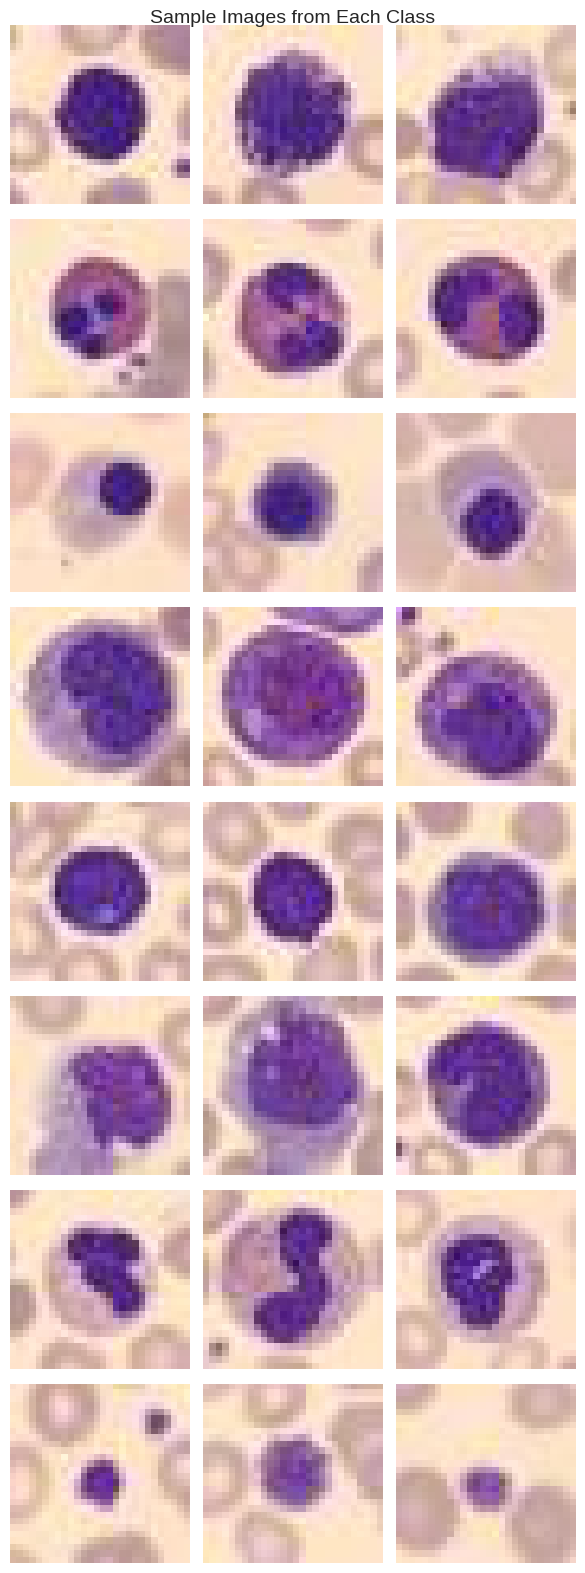

In [ ]:
# ============================================================
# Visualize sample images from each class
# ============================================================

def visualize_samples_per_class(dataset, class_names, n_samples=3):
    """Visualize n_samples from each class."""
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_samples, figsize=(n_samples * 2, n_classes * 2))

    # Collect samples for each class and plot them
    # Collect samples per class
    class_samples = defaultdict(list)
    for img, label in dataset:
        label_idx = label[0]
        if len(class_samples[label_idx]) < n_samples:
            class_samples[label_idx].append(img)
        if all(len(v) >= n_samples for v in class_samples.values()):
            break


    for class_idx in range(n_classes):
        for sample_idx in range(n_samples):
            ax = axes[class_idx, sample_idx]
            if sample_idx < len(class_samples[class_idx]):
                img = class_samples[class_idx][sample_idx]
                ax.imshow(img)
            ax.axis('off')
            if sample_idx == 0:
                ax.set_ylabel(f'{class_idx}: {class_names[class_idx][:10]}',
                             fontsize=10, rotation=0, ha='right', va='center')


    plt.suptitle('Sample Images from Each Class', fontsize=14)
    plt.tight_layout()
    plt.show()

# Call the function
visualize_samples_per_class(train_dataset_raw, class_names, n_samples=3)

# ============================================================

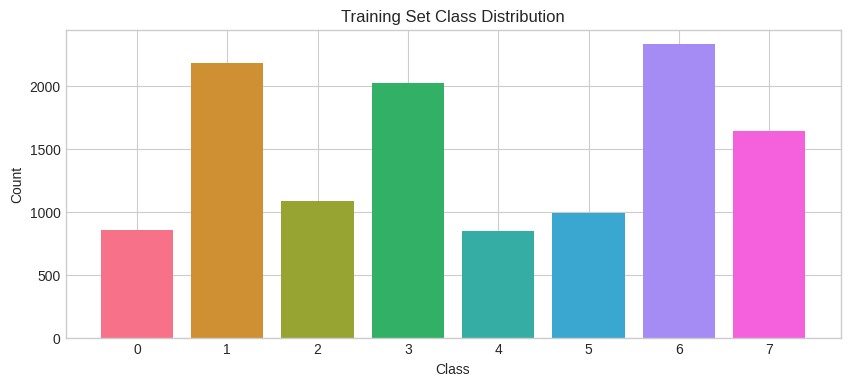

Class distribution:
  0: basophil: 852 (7.1%)
  1: eosinophil: 2181 (18.2%)
  2: erythroblast: 1085 (9.1%)
  3: immature granulocytes(myelocytes, metamyelocytes and promyelocytes): 2026 (16.9%)
  4: lymphocyte: 849 (7.1%)
  5: monocyte: 993 (8.3%)
  6: neutrophil: 2330 (19.5%)
  7: platelet: 1643 (13.7%)


In [ ]:
# Class distribution
def get_class_distribution(dataset):
    labels = [label[0] for _, label in dataset]
    return np.bincount(labels, minlength=n_classes)

train_dist = get_class_distribution(train_dataset_raw)

plt.figure(figsize=(10, 4))
plt.bar(range(n_classes), train_dist, color=sns.color_palette("husl", n_classes))
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Training Set Class Distribution')
plt.xticks(range(n_classes), [f'{i}' for i in range(n_classes)])
plt.show()

print("Class distribution:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}: {train_dist[i]} ({train_dist[i]/train_dist.sum()*100:.1f}%)")

---
## 4. Data Preprocessing

In [ ]:
# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms (with data augmentation)
train_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),  # Reduced from 15
    transforms.ColorJitter(brightness=0.05, contrast=0.05),  # Reduced
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# =====================================================================
# Validation/test transform (no augmentation)
# =====================================================================
val_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
# ============================================================

# Create datasets
train_dataset = DataClass(split='train', transform=train_transform, download=Config.DOWNLOAD)
val_dataset = DataClass(split='val', transform=val_transform, download=Config.DOWNLOAD)
test_dataset = DataClass(split='test', transform=val_transform, download=Config.DOWNLOAD)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Data loaders created: {len(train_loader)} train batches, {len(test_loader)} test batches")

Data loaders created: 187 train batches, 54 test batches


---
## 5. Model Definitions

### TransferLearningModel class

Implement **two models**:
1. **ResNet50**
2. **Googlenet**


In [ ]:
class TransferLearningModel(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True):
        super(TransferLearningModel, self).__init__()
        self.model_name = model_name

        # ============================================================
        # Load pretrained model and modify the final layer
        # ============================================================

        if model_name == 'resnet50':
            weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
            self.model = resnet50(weights=weights)
            # Modify the final layer
            in_features = self.model.fc.in_features
            self.model.fc = nn.Linear(in_features, num_classes)

        # Add elif blocks for second model choice
        elif model_name == 'googlenet':
            weights = GoogLeNet_Weights.IMAGENET1K_V1 if pretrained else None
            self.model = googlenet(weights=weights, aux_logits=True)
            # Main classifier
            in_features = self.model.fc.in_features
            self.model.fc = nn.Linear(in_features, num_classes)
            # Auxiliary classifiers
            if self.model.aux_logits:
                self.model.aux1.fc2 = nn.Linear(1024, num_classes)
                self.model.aux2.fc2 = nn.Linear(1024, num_classes)

        else:
            raise ValueError(f"Unknown model: {model_name}")

        # ============================================================

    def forward(self, x):
        return self.model(x)

    def get_num_params(self):
        """Return total and trainable parameters."""
        total = sum(p.numel() for p in self.model.parameters())
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        return total, trainable

In [ ]:
# ============================================================
# Create two model instances
# Model 1 ResNet50
# Model 2 GoogLeNet
# ============================================================

model_1_name = 'ResNet50'
model_1 = TransferLearningModel('resnet50', num_classes=n_classes).to(device)

model_2_name = 'GoogLeNet'
model_2 = TransferLearningModel('googlenet', num_classes=n_classes).to(device)

# ============================================================

# Store models in a dictionary
models_dict = {
    model_1_name: model_1,
    model_2_name: model_2
}

# Print model parameters
for name, model in models_dict.items():
    if model is not None:
        total, trainable = model.get_num_params()
        print(f"{name}: {total:,} total parameters ({trainable:,} trainable)")

ResNet50: 23,524,424 total parameters (23,524,424 trainable)
GoogLeNet: 9,954,488 total parameters (9,954,488 trainable)


---
## 6. Loss Function and Optimizers

In [ ]:
# Class weights for imbalanced data
def calculate_class_weights(distribution):
    total = distribution.sum()
    weights = total / (len(distribution) * distribution)
    weights = weights / weights.sum() * len(weights)
    return torch.FloatTensor(weights)

class_weights = calculate_class_weights(train_dist)

print("Class weights:")
for i, (name, weight) in enumerate(zip(class_names, class_weights)):
    print(f"  {name}: {weight:.4f}")

# Add check - if any weight is too large, cap it
max_weight = class_weights.max()
if max_weight > 10:
    print(f"WARNING: Max class weight is {max_weight:.2f}, clipping to 10")
    class_weights = torch.clamp(class_weights, max=10.0)

# ============================================================
# Define the loss function with class weights
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
# ============================================================

# Create optimizers and schedulers for each model
optimizers = {}
schedulers = {}

for name, model in models_dict.items():
    if model is not None:
        # ============================================================
        # Create optimizer and learning rate scheduler
        # ============================================================
        optimizers[name] = torch.optim.AdamW(
            model.parameters(),
            lr=Config.LEARNING_RATE,
            weight_decay=Config.WEIGHT_DECAY
        )
        schedulers[name] = CosineAnnealingLR(optimizers[name], T_max=Config.NUM_EPOCHS)
        # ============================================================

print("Loss and optimizers configured.")

Class weights:
  basophil: 1.4975
  eosinophil: 0.5850
  erythroblast: 1.1759
  immature granulocytes(myelocytes, metamyelocytes and promyelocytes): 0.6298
  lymphocyte: 1.5028
  monocyte: 1.2849
  neutrophil: 0.5476
  platelet: 0.7766
Loss and optimizers configured.


---
## 7. Training Functions

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, model_name):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()


        if model_name == 'GoogLeNet' and model.training:
            outputs = model(images)
            if isinstance(outputs, tuple):
                # GoogLeNet returns (main_output, aux1, aux2)
                main_output = outputs[0]
                loss = criterion(main_output, labels)

                # Add auxiliary losses if they exist
                if len(outputs) > 1 and outputs[1] is not None:
                    loss += 0.3 * criterion(outputs[1], labels)
                if len(outputs) > 2 and outputs[2] is not None:
                    loss += 0.3 * criterion(outputs[2], labels)

                outputs = main_output  # Use main output for metrics
            else:
                loss = criterion(outputs, labels)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        # ============================================================
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    # ============================================================
    # The validation loop
    # ============================================================

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validating', leave=False):
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            # Track statistics
            running_loss += loss.item() * images.size(0)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # ============================================================

    return running_loss / total, 100. * correct / total, np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [ ]:
def train_model(model, model_name, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, model_name)
        val_loss, val_acc, val_preds, val_labels, val_probs = validate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    return model, history

---
## 8. Train Models

Run training for both models. This may take 10-20 minutes per model depending on your hardware.

In [ ]:
# ============================================================
# Train both models and store histories
# ============================================================

all_histories = {}

# Loop through each model in models_dict to train them
for name, model in models_dict.items():
    if model is not None:
        model_trained, history = train_model(
            model=model,
            model_name=name,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizers[name],
            scheduler=schedulers[name],
            num_epochs=Config.NUM_EPOCHS,
            device=device
        )

        models_dict[name] = model_trained
        all_histories[name] = history

# ============================================================

print("\nTraining complete!")


Training ResNet50


Training:   0%|          | 0/187 [00:00<?, ?it/s]

Validating:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 1/20
Train Acc: 85.43% | Val Acc: 88.43%
Train Loss: 0.4506 | Val Loss: 0.2968%


Training:   0%|          | 0/187 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 19/20
Train Acc: 99.83% | Val Acc: 98.01%
Train Loss: 0.0108 | Val Loss: 0.0737%


Training:   0%|          | 0/187 [00:00<?, ?it/s]

Validating:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 20/20
Train Acc: 99.82% | Val Acc: 98.13%
Train Loss: 0.0095 | Val Loss: 0.0756%
Best validation accuracy: 98.13%

Training complete!


---
## 9. Learning Curves

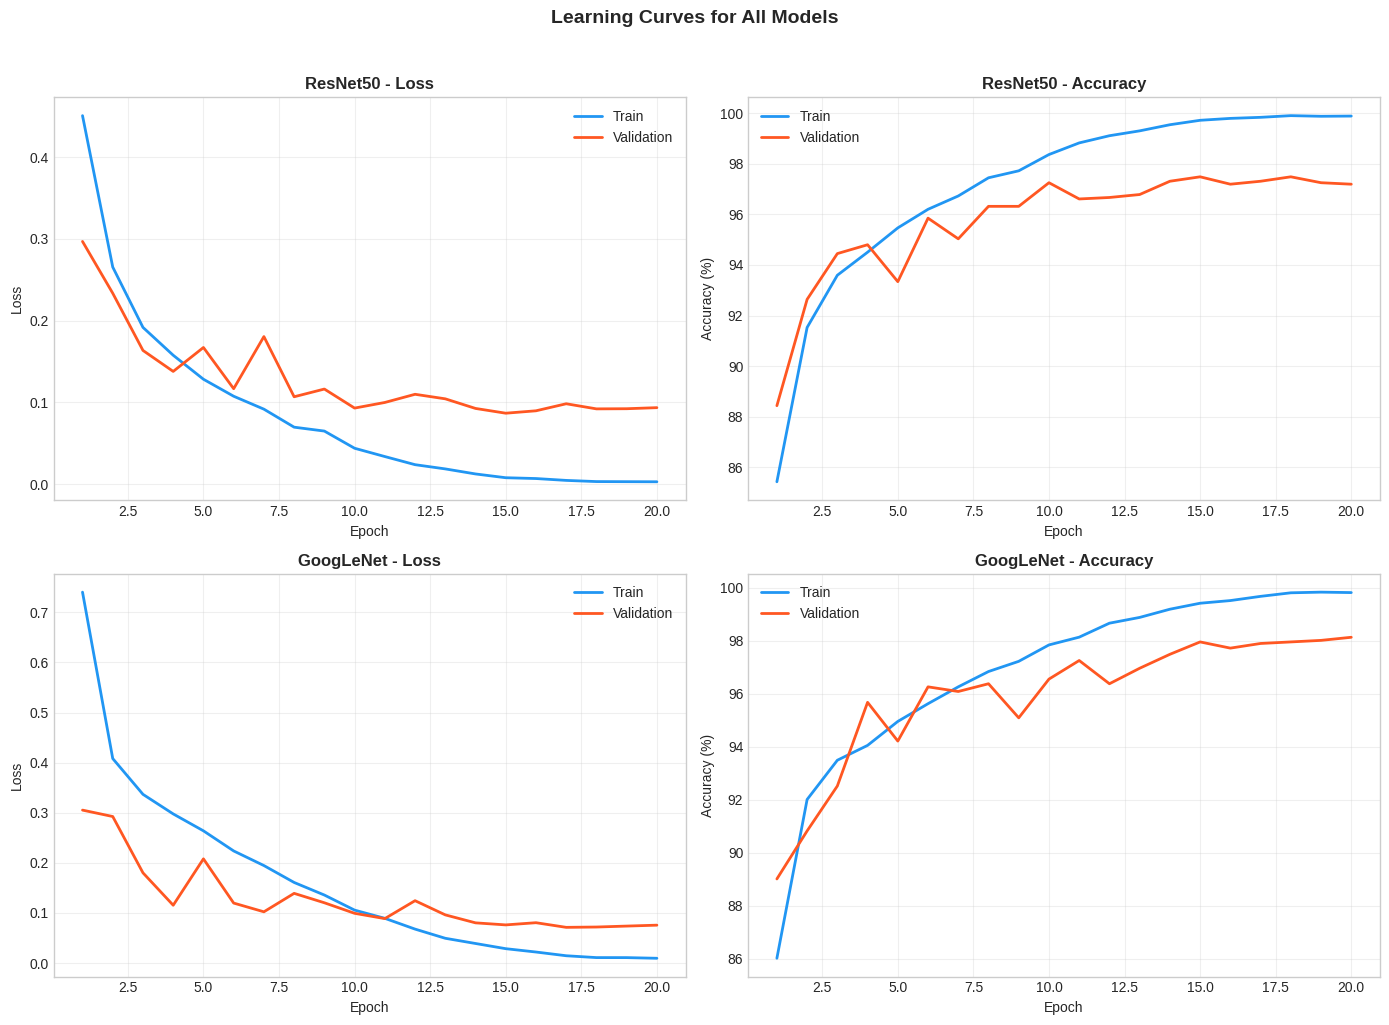

In [ ]:
# ============================================================
# Plot learning curves (loss and accuracy)
# ============================================================

fig, axes = plt.subplots(len(all_histories), 2, figsize=(14, 5 * len(all_histories)))
if len(all_histories) == 1:
    axes = np.expand_dims(axes, axis=0)

colors = {'train': '#2196F3', 'val': '#FF5722'}

for idx, (name, history) in enumerate(all_histories.items()):
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss curves
    axes[idx, 0].plot(epochs, history['train_loss'], label='Train', color=colors['train'], linewidth=2)
    axes[idx, 0].plot(epochs, history['val_loss'], label='Validation', color=colors['val'], linewidth=2)
    axes[idx, 0].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)

    # Accuracy curves
    axes[idx, 1].plot(epochs, history['train_acc'], label='Train', color=colors['train'], linewidth=2)
    axes[idx, 1].plot(epochs, history['val_acc'], label='Validation', color=colors['val'], linewidth=2)
    axes[idx, 1].set_title(f'{name} - Accuracy', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Accuracy (%)')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.suptitle('Learning Curves for All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# ============================================================

---
## 10. Ensemble Methods

### Implement the Ensemble Class

For `ensemble_average` and `ensemble_voting` methods.

In [ ]:
class EnsembleModel:
    def __init__(self, models_dict, device):
        self.models = models_dict
        self.device = device

    def predict_proba(self, images, model_name):
        """Get probability predictions from a single model."""
        model = self.models[model_name]
        model.eval()
        with torch.no_grad():
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            probs = F.softmax(outputs, dim=1)
        return probs

    def ensemble_average(self, images):
        """
        Ensemble by averaging probabilities from all models.

        Returns:
            predictions: argmax of averaged probabilities
            avg_probs: averaged probability distribution
        """
        all_probs = []

        # Iterate over model names in the dictionary
        for name in self.models.keys():
            probs = self.predict_proba(images, name)
            all_probs.append(probs)

        # Average probabilities
        avg_probs = torch.stack(all_probs).mean(dim=0)
        predictions = avg_probs.argmax(dim=1)

        return predictions, avg_probs

    def ensemble_voting(self, images):
        """
        Ensemble by majority voting.

        Returns:
            votes: majority vote predictions
            avg_probs: averaged probabilities (for confidence)
        """
        all_preds = []
        all_probs = []

        # Iterate over model names in the dictionary
        for name in self.models.keys():
            probs = self.predict_proba(images, name)
            preds = probs.argmax(dim=1)
            all_preds.append(preds)
            all_probs.append(probs)

        # Stack predictions: [n_models, batch_size]
        stacked_preds = torch.stack(all_preds)

        # Majority voting
        votes, _ = torch.mode(stacked_preds, dim=0)

        # Average probabilities for confidence
        avg_probs = torch.stack(all_probs).mean(dim=0)

        return votes, avg_probs

# Create ensemble
ensemble = EnsembleModel(models_dict, device)
print("Ensemble model created.")

Ensemble model created.


---
## 11. Evaluate All Models on Test Set

### The evaluation loop

In [ ]:
# Evaluate individual models
individual_results = {}

for name, model in models_dict.items():
    if model is not None:
        _, test_acc, preds, labels, probs = validate(model, test_loader, criterion, device)
        individual_results[name] = {
            'accuracy': test_acc,
            'predictions': preds,
            'labels': labels,
            'probabilities': probs
        }
        print(f"{name} Test Accuracy: {test_acc:.2f}%")

Validating:   0%|          | 0/54 [00:00<?, ?it/s]

ResNet50 Test Accuracy: 97.90%


Validating:   0%|          | 0/54 [00:00<?, ?it/s]

GoogLeNet Test Accuracy: 98.13%


In [ ]:
# ============================================================
# Evaluate ensemble methods on test set
# ============================================================

def evaluate_ensemble(ensemble, loader, device, method='average'):
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in tqdm(loader, desc=f'Ensemble {method}', leave=False):
        images = images.to(device)
        labels = labels.squeeze().long()

        if method == 'average':
            preds, probs = ensemble.ensemble_average(images)
        elif method == 'voting':
            preds, probs = ensemble.ensemble_voting(images)
        else:
            # Default to average if method unknown
            preds, probs = ensemble.ensemble_average(images)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

ensemble_results = {}
# Only 'average' and 'voting' are implemented in the EnsembleModel class
for method in ['average', 'voting']:
    preds, labels, probs = evaluate_ensemble(
        ensemble, test_loader, device, method=method
    )
    accuracy = accuracy_score(labels, preds) * 100
    ensemble_results[f'Ensemble ({method})'] = {
        'predictions': preds,
        'labels': labels,
        'probabilities': probs,
        'accuracy': accuracy
    }
    print(f"Ensemble ({method}) Test Accuracy: {accuracy:.2f}%")

# ============================================================

Ensemble average:   0%|          | 0/54 [00:00<?, ?it/s]

Ensemble (average) Test Accuracy: 98.42%


Ensemble voting:   0%|          | 0/54 [00:00<?, ?it/s]

Ensemble (voting) Test Accuracy: 98.01%


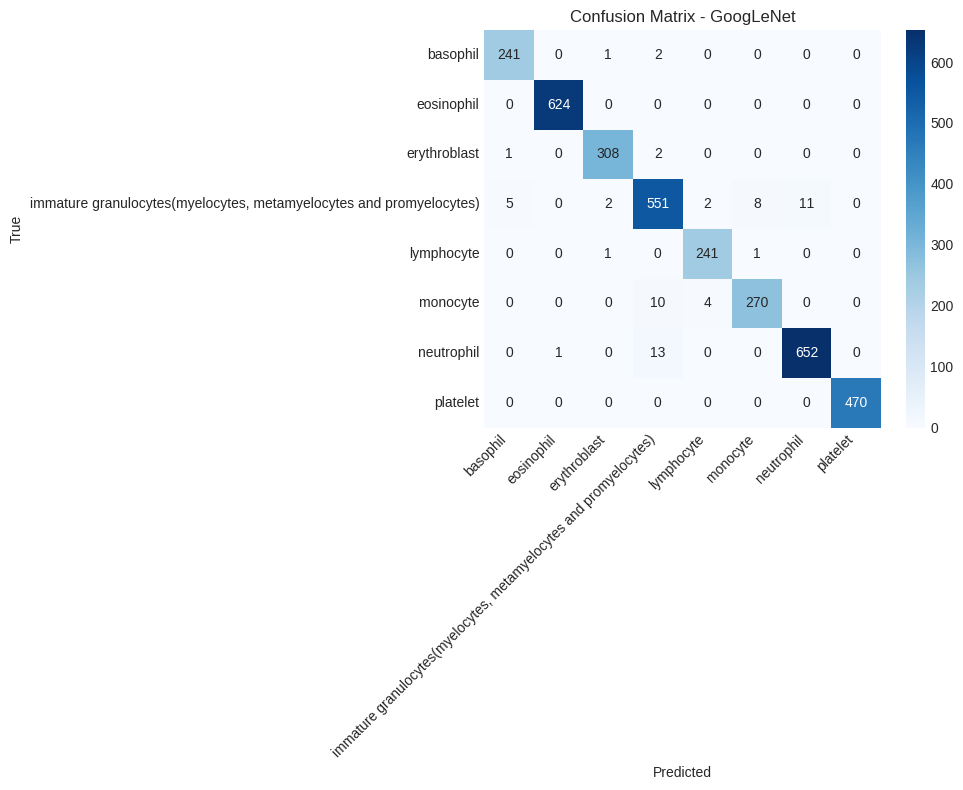

In [ ]:
# Confusion matrix for best individual model
best_individual = max(individual_results.items(), key=lambda x: x[1]['accuracy'])
best_name, best_results = best_individual

cm = confusion_matrix(best_results['labels'], best_results['predictions'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Print classification reports
print("="*60)
print(f"Best Model Classification Report: {best_name}")
print("="*60)
print(classification_report(best_results['labels'], best_results['predictions'],
                            target_names=class_names, digits=3))

Classification Report: GoogLeNet
                                                                     precision    recall  f1-score   support

                                                           basophil      0.976     0.988     0.982       244
                                                         eosinophil      0.998     1.000     0.999       624
                                                       erythroblast      0.987     0.990     0.989       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)      0.953     0.952     0.952       579
                                                         lymphocyte      0.976     0.992     0.984       243
                                                           monocyte      0.968     0.951     0.959       284
                                                         neutrophil      0.983     0.979     0.981       666
                                                           platelet      1.000     1.000     1

In [ ]:
# Compare all results
print("\n" + "="*60)
print("FINAL RESULTS COMPARISON")
print("="*60)

all_results = {**individual_results, **ensemble_results}

results_data = []
for name, res in all_results.items():
    model_type = 'Ensemble' if 'Ensemble' in name else 'Individual'
    precision, recall, f1, _ = precision_recall_fscore_support(
        res['labels'], res['predictions'], average='macro'
    )
    results_data.append({
        'Model': name,
        'Type': model_type,
        'Accuracy (%)': res['accuracy'],
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results_data).sort_values('Accuracy (%)', ascending=False)
print(results_df.to_string(index=False))


FINAL RESULTS COMPARISON
             Model       Type  Accuracy (%)  Precision   Recall  F1-Score
Ensemble (average)   Ensemble     98.421514   0.983914 0.984371  0.984127
         GoogLeNet Individual     98.129202   0.980179 0.981394  0.980763
 Ensemble (voting)   Ensemble     98.012277   0.978897 0.979221  0.978965
          ResNet50 Individual     97.895352   0.977829 0.978827  0.978295


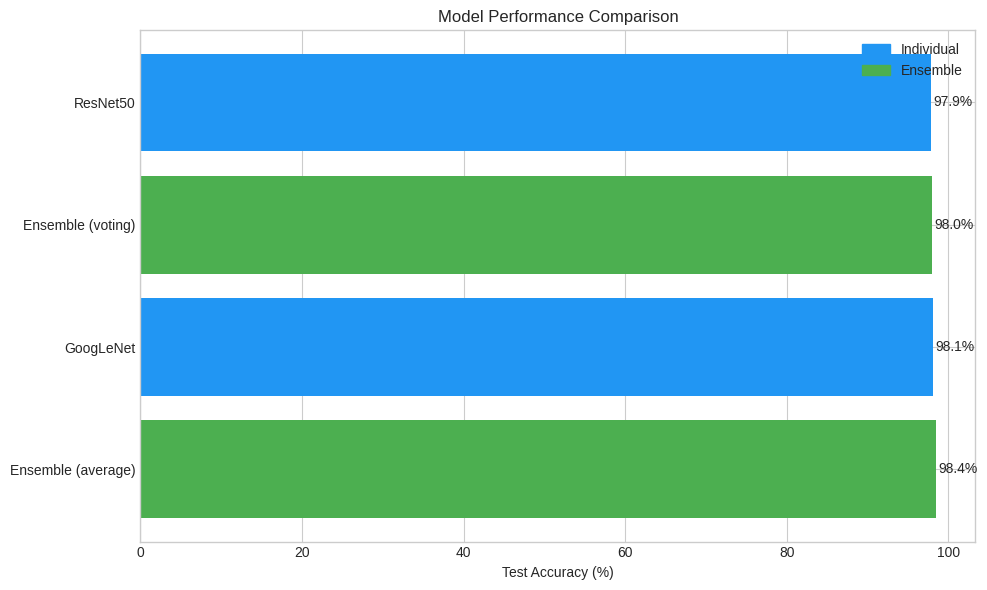

In [ ]:
# Bar chart comparison
plt.figure(figsize=(10, 6))
colors = ['#2196F3' if 'Ensemble' not in m else '#4CAF50' for m in results_df['Model']]
bars = plt.barh(results_df['Model'], results_df['Accuracy (%)'], color=colors)
plt.xlabel('Test Accuracy (%)')
plt.title('Model Performance Comparison')

for bar, acc in zip(bars, results_df['Accuracy (%)']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{acc:.1f}%', va='center')

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#2196F3', label='Individual'),
                    Patch(color='#4CAF50', label='Ensemble')])
plt.tight_layout()
plt.show()

---
## 13. Analysis Questions

### Question 1

Compare the test accuracy of your two individual models. Which model performed better? Provide at least **two possible reasons** why one model outperformed the other, considering factors like model architecture, number of parameters, or training dynamics.

**Answer:**

Between the two individual models, **GoogLeNet achieved slightly better test accuracy (98.13%) compared to ResNet50 (97.90%),** a difference of 0.23 percentage points.

From understanding the two models, I realized first that their architectures are quite different but both use convolutional layers. On one hand, ResNet50 uses residual connections (skip connections) that allow gradients to flow directly through the network by adding the input of a layer to its output. On the other hand, GoogLeNet uses Inception modules that apply multiple filter sizes (1x1, 3x3, 5x5) in parallel at the same level, then concatenate the results. This captures features at different scales simultaneously.

So two key reasons why GoogLeNet outperformed ResNet50 could be:
1. **GoogLeNet's Architecture is better for this dataset**: GoogLeNet uses Inception modules that look at images at multiple scales at the same time This is really helpful for blood cell images because cells have features of different sizes, some details are small like textures inside cells, while others are bigger like the overall cell shape. ResNet50 processes features more sequentially, so it might miss some of these multi-scale patterns.

2. **GoogLeNet had better training and converged more smoothly**: GoogLeNet uses auxiliary classifiers during training - basically extra outputs in the middle of the network that also calculate loss. This helps the network learn better throughout all its layers, not just at the end. ResNet50 doesn't have this feature.

Overall: GoogLeNet's multi-scale processing worked better for blood cell features, and having fewer parameters helped it generalize better on this smaller dataset.

### Question 2

Did the ensemble methods outperform the individual models? Compare the **average probability** ensemble vs **majority voting** ensemble. Which performed better and why might this be the case?

**Answer:**

Yes, **the ensemble methods performed better than both individual models**. The average probability ensemble achieved the best performance at 98.42%, compared to GoogLeNet (98.13%) and ResNet50 (97.90%). The majority voting ensemble got 98.01%, which still beat ResNet50 but was slightly lower than GoogLeNet alone.

The average probability ensemble performed better than majority voting **(98.42% vs 98.01%)**. This makes sense because average probability uses more information from each model. When we average the probabilities, we're combining the confidence scores from both models, so if one model is really confident about a prediction and the other is less sure, that gets factored in. Majority voting just looks at the final class prediction, so it loses all that nuanced probability information. Basically, averaging probabilities lets the models "communicate" better about how certain they are, which leads to smarter predictions overall.

### Question 3

Looking at the confusion matrix and per-class metrics, which blood cell types were **most difficult to classify**? Propose one reason why these classes might be challenging and one potential solution to improve classification for these classes.

**Answer:**

Looking at the confusion matrix, **immature granulocytes and monocytes were the most difficult to classify.**

Immature granulocytes had the most misclassifications - it confused 11 samples with neutrophils, 8 with monocytes, and small numbers with other classes. Only 551 out of 579 were classified correctly.

Monocytes also struggled with 10 misclassifications as immature granulocytes and 4 as lymphocytes, with 270 out of 284 correct predictions.

***So why might this happen?***
These cell types probably look really similar to each other under a microscope. According to my findings, Immature granulocytes and mature neutrophils are actually from the same cell lineage, so they share a lot of visual features. Monocytes and lymphocytes are both types of white blood cells with similar sizes and shapes, making them easy to confuse.

**Potential solutions:**
Data augumention specifically for the classes that have the challenge. Like creating more training data with varying rotations, color and zoom. Another potential solution could be adjusting the class weight to pay more attention to learing distinguishing features.

### Question 4

In this notebook, we used only **two models** for the ensemble. Based on the another material (which used four models), do you think adding more models would improve ensemble performance? What are the **trade-offs** of using more models in an ensemble?

**Answer:**

Based on what we learned in the other notebook with four models, I think adding more models would likely improve performance, but with no significant return.

Going from 1 model to 2 models gave us a nice boost (from 98.13% to 98.42% with averaging), which is a 0.29 percentage point improvement. Adding a third and fourth model would probably give us another small improvement, maybe getting us to 98.6-98.7%, but each additional model helps less than the previous one.

The key is that additional models need to be different enough to make mistakes on different samples. If we added more models with a completely different architecture it might capture different patterns and improve the ensemble more.

However, there's also a practical trade-off, more models mean more training time, more memory, and slower inference. For this dataset where we're already at 98.42%, the extra 0.2-0.3% accuracy might not be worth quadrupling the computational costs.
